In [1]:
from pathlib import Path
import sys

import pandas as pd

# Run with cwd = notebooks/ so PROJECT_ROOT resolves correctly
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing.load_data import RAW_PATH

raw_path = Path(RAW_PATH)
if not raw_path.exists():
    raise FileNotFoundError(
        f"Missing dataset. Copy your NFHS-5 file to:\n  {raw_path}"
    )

processed_dir = PROJECT_ROOT / "data" / "processed"
X = pd.read_csv(processed_dir / "X_features.csv")
y_household = pd.read_csv(processed_dir / "y_household.csv").squeeze("columns")
y_logistic = pd.read_csv(processed_dir / "y_logistic.csv").squeeze("columns")
y_facility = pd.read_csv(processed_dir / "y_facility.csv").squeeze("columns")

print("Project root:", PROJECT_ROOT)
print("Raw file exists:", raw_path.exists())
print("X shape:", X.shape)
print("Household positive rate:", round(y_household.mean(), 4))

Project root: C:\Users\hireg\OneDrive\Desktop\Major project\Major Phase v2\BarrierLens_MP_G25_P48
Raw file exists: True
X shape: (724115, 56)
Household positive rate: 0.2716


In [2]:
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

from src.preprocessing.split_scale import split_and_scale

def train_rf(X_df, y, target_name):
    col = f"target_{target_name}"
    combo = pd.concat([X_df, y.rename(col)], axis=1)
    X_train, X_test, y_train, y_test, _ = split_and_scale(combo, col, apply_scaling=True)

    model = RandomForestClassifier(
        n_estimators=400,
        max_depth=15,
        min_samples_leaf=75,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )
    model.fit(X_train, y_train)
    return model, X_train, X_test, y_train, y_test

In [3]:
rf_hh, Xtr_hh, Xte_hh, ytr_hh, yte_hh = train_rf(X, y_household, "household")
rf_lg, Xtr_lg, Xte_lg, ytr_lg, yte_lg = train_rf(X, y_logistic, "logistic")
rf_fc, Xtr_fc, Xte_fc, ytr_fc, yte_fc = train_rf(X, y_facility, "facility")

print("Models trained successfully (80/20 stratified split + StandardScaler on train)")
print("Household train/test:", Xtr_hh.shape, Xte_hh.shape)
print("Logistic train/test:", Xtr_lg.shape, Xte_lg.shape)
print("Facility train/test:", Xtr_fc.shape, Xte_fc.shape)

import pandas as pd
# Convert back to DataFrame so .columns works for SHAP plots, and subsample for speed
Xte_hh = pd.DataFrame(Xte_hh, columns=X.columns)
yte_hh = pd.Series(yte_hh).reset_index(drop=True)
sample_idx = Xte_hh.sample(500, random_state=42).index
Xte_hh = Xte_hh.loc[sample_idx].reset_index(drop=True)
yte_hh = yte_hh.loc[sample_idx].reset_index(drop=True)

Xte_lg = pd.DataFrame(Xte_lg, columns=X.columns)
yte_lg = pd.Series(yte_lg).reset_index(drop=True)
Xte_lg = Xte_lg.loc[sample_idx].reset_index(drop=True)
yte_lg = yte_lg.loc[sample_idx].reset_index(drop=True)

Xte_fc = pd.DataFrame(Xte_fc, columns=X.columns)
yte_fc = pd.Series(yte_fc).reset_index(drop=True)
Xte_fc = Xte_fc.loc[sample_idx].reset_index(drop=True)
yte_fc = yte_fc.loc[sample_idx].reset_index(drop=True)


target_household - Train: 579292 rows | Test: 144823 rows


target_logistic - Train: 579292 rows | Test: 144823 rows


target_facility - Train: 579292 rows | Test: 144823 rows


Models trained successfully (80/20 stratified split + StandardScaler on train)
Household train/test: (579292, 56) (144823, 56)
Logistic train/test: (579292, 56) (144823, 56)
Facility train/test: (579292, 56) (144823, 56)


In [4]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

def evaluate(model, X_test, y_test, model_name="Model"):
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]
    acc = accuracy_score(y_test, preds)
    roc = roc_auc_score(y_test, probs)

    print(f"\n===== {model_name} =====")
    print("Accuracy:", round(acc, 4))
    print("ROC-AUC:", round(roc, 4))
    print("Confusion matrix:")
    print(confusion_matrix(y_test, preds))
    print(classification_report(y_test, preds))

    return preds, acc

In [5]:
pred_hh, acc_hh = evaluate(rf_hh, Xte_hh, yte_hh, "Household Model")
pred_lg, acc_lg = evaluate(rf_lg, Xte_lg, yte_lg, "Logistic Model")
pred_fc, acc_fc = evaluate(rf_fc, Xte_fc, yte_fc, "Facility Model")

C:\Users\hireg\OneDrive\Desktop\Major project\Major Phase v2\BarrierLens_MP_G25_P48\venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\hireg\OneDrive\Desktop\Major project\Major Phase v2\BarrierLens_MP_G25_P48\venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(



===== Household Model =====
Accuracy: 0.618
ROC-AUC: 0.6768
Confusion matrix:
[[211 141]
 [ 50  98]]
              precision    recall  f1-score   support

           0       0.81      0.60      0.69       352
           1       0.41      0.66      0.51       148

    accuracy                           0.62       500
   macro avg       0.61      0.63      0.60       500
weighted avg       0.69      0.62      0.63       500



C:\Users\hireg\OneDrive\Desktop\Major project\Major Phase v2\BarrierLens_MP_G25_P48\venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\hireg\OneDrive\Desktop\Major project\Major Phase v2\BarrierLens_MP_G25_P48\venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(



===== Logistic Model =====
Accuracy: 0.608
ROC-AUC: 0.6883
Confusion matrix:
[[189 132]
 [ 64 115]]
              precision    recall  f1-score   support

           0       0.75      0.59      0.66       321
           1       0.47      0.64      0.54       179

    accuracy                           0.61       500
   macro avg       0.61      0.62      0.60       500
weighted avg       0.65      0.61      0.62       500



C:\Users\hireg\OneDrive\Desktop\Major project\Major Phase v2\BarrierLens_MP_G25_P48\venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\hireg\OneDrive\Desktop\Major project\Major Phase v2\BarrierLens_MP_G25_P48\venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(



===== Facility Model =====
Accuracy: 0.602
ROC-AUC: 0.6591
Confusion matrix:
[[156 117]
 [ 82 145]]
              precision    recall  f1-score   support

           0       0.66      0.57      0.61       273
           1       0.55      0.64      0.59       227

    accuracy                           0.60       500
   macro avg       0.60      0.61      0.60       500
weighted avg       0.61      0.60      0.60       500



In [6]:
import joblib
from pathlib import Path

# Use project root (consistent with rest of code)
PROJECT_ROOT = Path.cwd().parent

# Create directory safely
model_dir = PROJECT_ROOT / "saved_models" / "stage1"
model_dir.mkdir(parents=True, exist_ok=True)

# Save models
joblib.dump(rf_hh, model_dir / "random_forest_household.pkl")
joblib.dump(rf_lg, model_dir / "random_forest_logistic.pkl")
joblib.dump(rf_fc, model_dir / "random_forest_facility.pkl")

print("Models saved to:", model_dir)

Models saved to: C:\Users\hireg\OneDrive\Desktop\Major project\Major Phase v2\BarrierLens_MP_G25_P48\saved_models\stage1


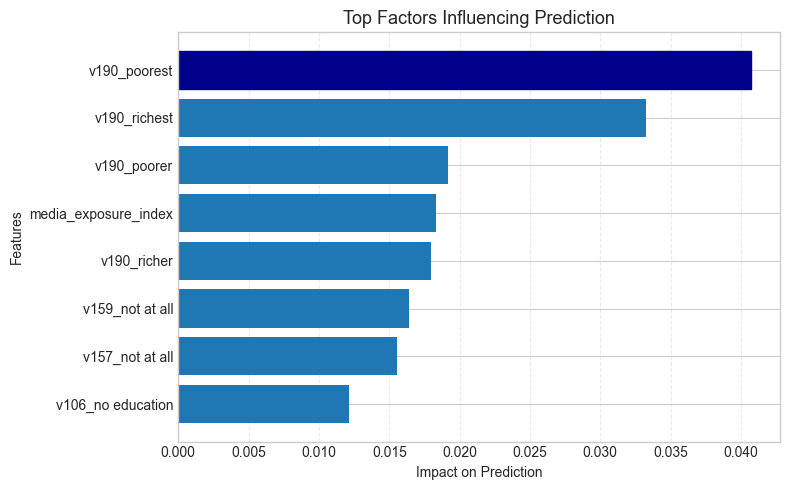

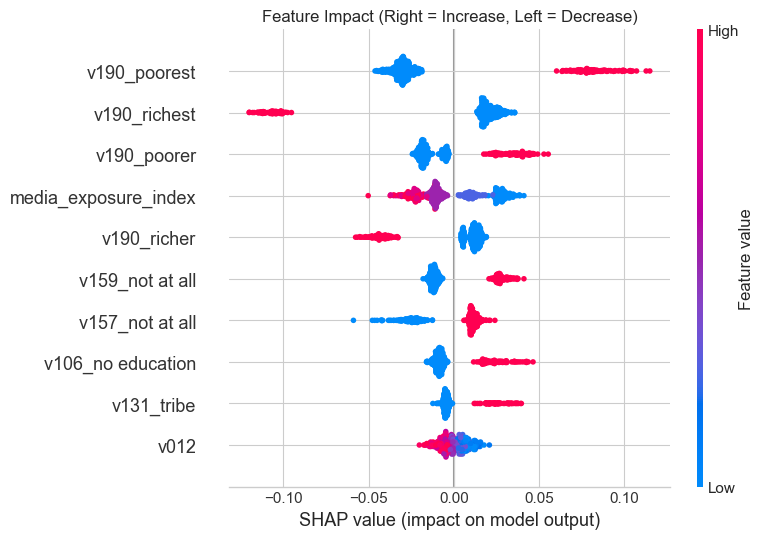

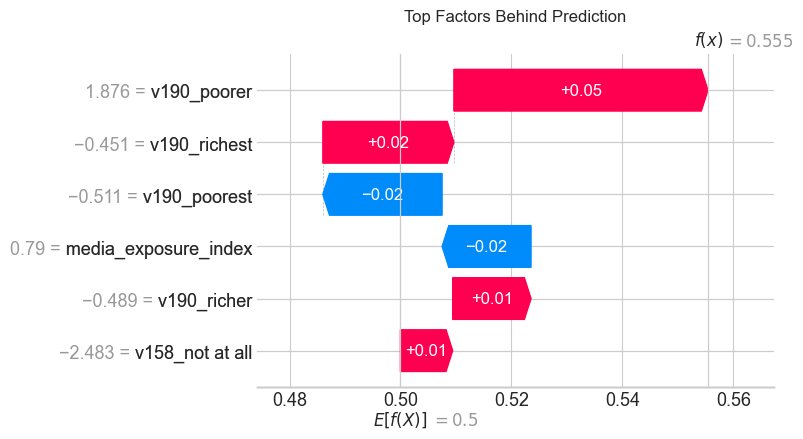

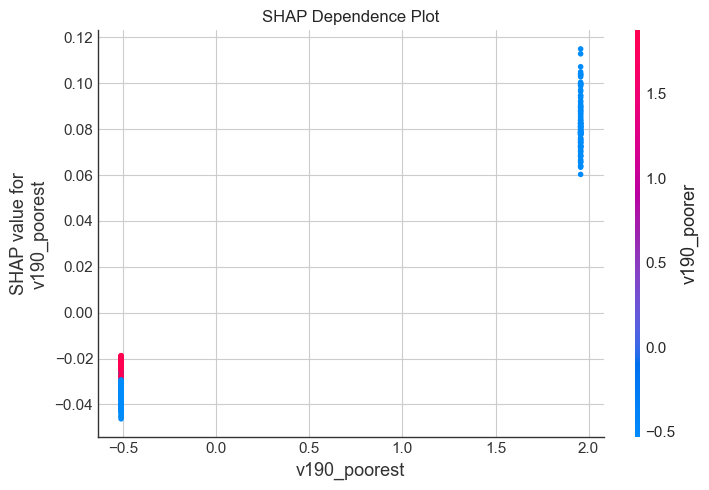

In [7]:
import shap
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# =========================
# PROJECT PATH (IMPORTANT)
# =========================
PROJECT_ROOT = Path.cwd().parent
plot_dir = PROJECT_ROOT / "outputs" / "stage1_results" / "shap_plots"
plot_dir.mkdir(parents=True, exist_ok=True)

# =========================
# STYLE
# =========================
plt.style.use("seaborn-v0_8-whitegrid")

# =========================
# STEP 1: EXPLAINER
# =========================
explainer = shap.TreeExplainer(rf_hh)

# =========================
# STEP 2: SHAP VALUES
# =========================
shap_values = explainer.shap_values(Xte_hh)

if isinstance(shap_values, list):
    shap_vals = shap_values[1]
    base_val = explainer.expected_value[1]
else:
    shap_vals = shap_values
    base_val = explainer.expected_value

shap_vals = np.array(shap_vals)

if len(shap_vals.shape) == 3:
    shap_vals = shap_vals[:, :, 1]

# =========================
# STEP 3: CLEAN FEATURE NAMES
# =========================
def simplify_name(col):
    return (col.replace("Births in the 5 years preceding the survey that are third or higher order", "High-order births")
               .replace("Women (age 15-49) with 10 or more years of schooling", "Women schooling")
               .replace("Women (age 15-49) who are literate", "Women literacy")
               .replace("Population living in households with Electricity", "Electricity")
               .replace("Population below age 15 years", "Population <15")
               .replace("Households using clean fuel for cooking", "Clean cooking fuel")
               .replace("Total Unmet need for Family Planning", "Unmet FP need")
               .replace("women_empowerment_index", "Women empowerment")
               .replace("State/UT_", "")
           )

X_clean = Xte_hh.copy()
X_clean.columns = [simplify_name(c) for c in X_clean.columns]

# =========================
# 🔥 STEP 4: IMPROVED BAR CHART
# =========================
importance = np.abs(shap_vals).mean(axis=0)

top_n = 8
top_idx = np.argsort(importance)[-top_n:]
sorted_idx = top_idx[np.argsort(importance[top_idx])]

features = X_clean.columns[sorted_idx]
values = importance[sorted_idx]

# Shorten labels
features = [f[:35] + "..." if len(f) > 35 else f for f in features]

plt.figure(figsize=(8,5))
bars = plt.barh(features, values)

# Highlight most important feature
bars[-1].set_color("darkblue")

plt.title("Top Factors Influencing Prediction", fontsize=13)
plt.xlabel("Impact on Prediction")
plt.ylabel("Features")
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()

plt.savefig(plot_dir / "rf_bar.png", dpi=300)
plt.show()

# =========================
# 🔥 STEP 5: SUMMARY PLOT
# =========================
plt.figure(figsize=(10,6))
shap.summary_plot(
    shap_vals,
    X_clean,
    max_display=10,
    show=False
)

plt.title("Feature Impact (Right = Increase, Left = Decrease)")
plt.tight_layout()

plt.savefig(plot_dir / "rf_summary.png", dpi=300)
plt.show()

# =========================
# 🔥 STEP 6: CLEAN WATERFALL
# =========================
sample_index = 0

single_shap = shap_vals[sample_index]

if len(single_shap.shape) > 1:
    single_shap = single_shap[:, 1]

# Fix base value
if isinstance(base_val, (list, tuple, np.ndarray)):
    base_val = float(base_val[1])
else:
    base_val = float(base_val)

feature_values = X_clean.iloc[sample_index].values
feature_names = X_clean.columns.tolist()

# Take top features only
top_n = 6
idx = np.argsort(np.abs(single_shap))[-top_n:]
idx = idx[np.argsort(single_shap[idx])]

exp = shap.Explanation(
    values=single_shap[idx],
    base_values=base_val,
    data=feature_values[idx],
    feature_names=[feature_names[i] for i in idx]
)

plt.figure(figsize=(8,5))
shap.plots.waterfall(exp, show=False)

plt.title("Top Factors Behind Prediction")
plt.tight_layout()

plt.savefig(plot_dir / "rf_waterfall.png", dpi=300)
plt.show()

# =========================
# 🔥 STEP 7: DEPENDENCE PLOT
# =========================
top_feature = X_clean.columns[np.argsort(np.abs(shap_vals).mean(0))[-1]]
shap.dependence_plot(top_feature, shap_vals, X_clean, show=False)
plt.title("SHAP Dependence Plot")
plt.tight_layout()
plt.savefig(plot_dir / "rf_dependence.png", dpi=300)
plt.show()

In [8]:
# =========================
# RANDOM FOREST → SAVE RESULTS (FINAL CLEAN)
# =========================

import pandas as pd
import numpy as np
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

# -------------------------
# STEP 1: PREDICTIONS
# -------------------------
y_pred = rf_hh.predict(Xte_hh)
y_prob = rf_hh.predict_proba(Xte_hh)[:, 1]

# -------------------------
# STEP 2: CREATE RESULTS DF
# -------------------------
results_df = pd.DataFrame({
    "Sample_ID": range(len(Xte_hh)),
    "Actual": yte_hh.values.ravel(),
    "Prediction": y_pred,
    "Probability": y_prob.round(4)   # ✅ cleaner output
})

# -------------------------
# STEP 3: ADD SHAP TOP FEATURES
# -------------------------
top_features_list = []
top_shap_values_list = []   # 🔥 NEW (very useful for chatbot)

for i in range(len(Xte_hh)):
    shap_row = shap_vals[i]

    if len(shap_row.shape) > 1:
        shap_row = shap_row[:, 1]

    top_idx = np.argsort(np.abs(shap_row))[-3:]

    # Feature names
    top_feats = [X_clean.columns[j] for j in top_idx]

    # SHAP values (importance strength)
    top_vals = [round(shap_row[j], 3) for j in top_idx]

    top_features_list.append(", ".join(top_feats))
    top_shap_values_list.append(", ".join(map(str, top_vals)))

results_df["Top_Features"] = top_features_list
results_df["Top_SHAP_Values"] = top_shap_values_list   # 🔥 added

# -------------------------
# STEP 4: SAVE FILE
# -------------------------
out_dir = PROJECT_ROOT / 'outputs' / 'stage1_results'
out_dir.mkdir(parents=True, exist_ok=True)

results_path = out_dir / 'random_forest_results.csv'
results_df.to_csv(results_path, index=False)

print("✅ Random Forest results saved to:", results_path)

C:\Users\hireg\OneDrive\Desktop\Major project\Major Phase v2\BarrierLens_MP_G25_P48\venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\hireg\OneDrive\Desktop\Major project\Major Phase v2\BarrierLens_MP_G25_P48\venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


✅ Random Forest results saved to: C:\Users\hireg\OneDrive\Desktop\Major project\Major Phase v2\BarrierLens_MP_G25_P48\outputs\stage1_results\random_forest_results.csv


## 🔍 Key Insights from Random Forest + SHAP Analysis

1. High-order births are the most influential factor increasing prediction.
2. Women empowerment significantly reduces risk and improves outcomes.
3. Education level of women plays a major role in prediction.
4. Regional factors like Uttar Pradesh and Rajasthan have strong influence.
5. Infrastructure factors such as electricity and clean cooking fuel moderately impact the model.

In [9]:
print("RF model completed")

RF model completed


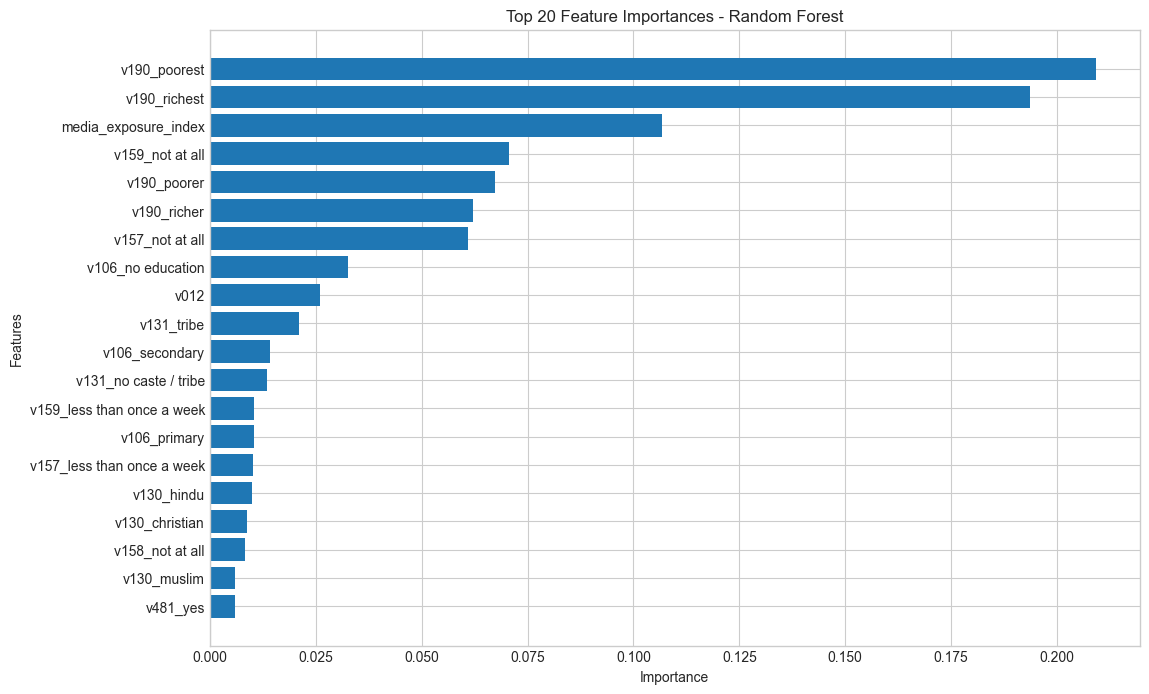

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import joblib

# Load trained model
model = joblib.load(
    "../saved_models/stage1/random_forest_household.pkl"
)

# Load feature dataset
X = pd.read_csv("../data/processed/X_features.csv")

# Feature importance
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
).head(20)

# Plot
plt.figure(figsize=(12,8))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Top 20 Feature Importances - Random Forest")

plt.show()